In [12]:
import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

import umap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
import matplotlib.colors as mcolors
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/combined_der_dataset_w_controls_predictors.csv")
df = df.drop(columns=['zip_code','overlap_area_m2','overlap_share_of_zip',
                      'utility','acronym','Unnamed: 0', 'lat', 'lon',
                      't2m_max_mean_c_2023', 't2m_min_mean_c_2023',
                      't2m_summer_mean_c_2023', "Unnamed: 0.1", 'pop_density_km2',
                      'kwh_annual_total', 'county_geoid', 'county_name', 'plant_capacity_mw'],
            errors='ignore')
print(df.columns)

Index(['PV_system_size_DC', 'total_chargers', 'level1_chargers',
       'level2_chargers', 'dc_fast_chargers', 'zev_count',
       'storage_capacity_mw', 'wind_capacity_mw', 'wind_turbine_count',
       'median_household_income', 'poverty_rate', 'pct_bachelors_plus',
       'pct_black', 'pct_hispanic', 'pct_asian', 'median_housing_value',
       'total_population', 'ghi_mean_kwh_m2_day_2024', 't2m_mean_c_2023',
       'cdd65_2023', 'hdd65_2023', 'wind_ws10m_mean_2024',
       'wind_ws50m_mean_2024', 'utility_type', 'log_kwh', 'area_km2',
       'log_pop_density'],
      dtype='object')


In [3]:
# safer missing handling
df["utility_type"] = df["utility_type"].fillna("POU")

population = df["total_population"].replace(0, np.nan)

rate_cols = {
    'PV_system_size_DC': ('pv_kw_per_1k', 1000.0),
    'total_chargers': ('chargers_per_1k', 1000.0),
    'zev_count': ('zev_per_1k', 1000.0),
    'storage_capacity_mw': ('storage_mw_per_100k', 100000.0),
    'wind_capacity_mw': ('wind_mw_per_100k', 100000.0),
    'wind_turbine_count': ('turbines_per_100k', 100000.0),
}

for col, (new_name, denom) in rate_cols.items():
    if col in df.columns:
        df[new_name] = df[col] / (population / denom)
        df.drop(columns=[col], inplace=True)

df.replace([np.inf, -np.inf], np.nan, inplace=True)

cluster_columns = ['UMAP_Cluster','PCA_Cluster','tSNE_Cluster',
'Cluster','RF_Cluster', 'cluster_z_pca', "cluster_z2_tsne", "cluster_z2_umap"]
df = df.drop(columns=[c for c in cluster_columns if c in df.columns], errors='ignore')

categorical_cols = ["utility_type"]
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[('cat', encoder, categorical_cols)],
    remainder='passthrough'
)

df_encoded = preprocessor.fit_transform(df)
df_encoded = pd.DataFrame(df_encoded, columns=preprocessor.get_feature_names_out())

# single imputation
imputer = SimpleImputer(strategy='median')
data_imputed = imputer.fit_transform(df_encoded)

scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(data_imputed)
clustering_data_scaled = pd.DataFrame(clustering_data_scaled, columns=df_encoded.columns)

rename_map = {}
for column in clustering_data_scaled.columns:
    if column[:3] == "cat":
        rename_map[column] = column[5:]
    else:
        rename_map[column] = column[11:]
clustering_data_scaled.rename(columns = rename_map, inplace = True)
stand_rename_map = {
    "cdd65_2023": "Cooling degree days",
    "stand_cdd65_2023": "Standardizde cooling degree days",
    "stand_hdd65_2023": "Standardizde heating degree days",
    "hdd65_2023": "Heating degree days",
    "ghi_mean_kwh_m2_day_2023": "Solar irradiance (GHI)",
    "wind_ws10m_mean_2023": "Wind speed (10m)",
    "wind_ws50m_mean_2023": "Wind speed (50m)",
    "poverty_rate": "Poverty rate",
    "pct_bachelors_plus": "% Bachelor's+",
    "pct_black": "% Black",
    "pct_hispanic": "% Hispanic",
    "pct_asian": "% Asian",
    "median_household_income": "Median household income",
    "log_median_housing_value": "Log median housing value",
    "median_housing_value": "Median housing value",
    "log_pop_density": "Log population density",
    "log_kwh": "Log annual electricity demand",
    "pv_kw_per_1k": "Solar PV adoption per 1k pop",
    "chargers_per_1k": "EV charger per 1k pop",
    "zev_per_1k": "EV cars per 1k pop",
    "storage_mw_per_100k": "Storage deployment per 1k pop",
    "wind_mw_per_100k": "Wind MW per 100k",
    "turbines_per_100k": "Number of turbines per 100k",
    "utility_type_IOU": "IOU Utility",
    "utility_type_POU": "POU Utility",
    "level1_chargers": "Number of Level 1 chargers",
    "level2_chargers": "Number of Level 2 chargers",
    "dc_fast_chargers": "Number of DC fast chargers",
    "utility_type": "Utility type",
    "total_population": "Total population",
    "area_km2": "Area in km2",
    "t2m_mean_c_2023": "Temp at 2m above ground",
    "ghi_mean_kwh_m2_day_2024": "Global horizontal irradiance",
    "wind_ws50m_mean_2024": "Mean wind speed at 50 m",
}
clustering_data_scaled.rename(columns = stand_rename_map, inplace = True)
print(clustering_data_scaled.describe())
num = 3
print(clustering_data_scaled.columns)

        IOU Utility   POU Utility  Number of Level 1 chargers  \
count  2.572000e+03  2.572000e+03                2.572000e+03   
mean   9.945388e-17 -3.315129e-17               -2.486347e-17   
std    1.000194e+00  1.000194e+00                1.000194e+00   
min   -1.338886e+00 -7.468894e-01               -6.915238e-02   
25%   -1.338886e+00 -7.468894e-01               -6.915238e-02   
50%    7.468894e-01 -7.468894e-01               -6.915238e-02   
75%    7.468894e-01  1.338886e+00               -6.915238e-02   
max    7.468894e-01  1.338886e+00                3.393348e+01   

       Number of Level 2 chargers  Number of DC fast chargers  \
count                2.572000e+03                2.572000e+03   
mean                 1.105043e-17               -2.762608e-18   
std                  1.000194e+00                1.000194e+00   
min                 -3.749404e-01               -5.967226e-01   
25%                 -1.710484e-01               -2.804055e-01   
50%                 -1.7

In [10]:
X = clustering_data_scaled.drop(columns=cluster_columns, errors="ignore")

# --------- clustering labels (UMAP 10D -> KMeans) ----------
def set_up_pca_kmeans(n_components, n_clusters):
  pca = PCA(n_components=n_components)
  Z_pca = pca.fit_transform(X)
  kmeans = KMeans(n_clusters=n_clusters, random_state=77, n_init="auto")
  labels = kmeans.fit_predict(Z_pca)
  df_viz_pca = X.copy()
  df_viz_pca["cluster_z_pca"] = labels
  print(df_viz_pca["cluster_z_pca"].value_counts().sort_index())

  return pca, df_viz_pca, Z_pca

In [5]:
def plot_clusters(Z, df_vis):
  # Plot colored by the "Cluster" labels
  plt.figure(figsize=(10, 6))
  plt.scatter(Z[:, 0], Z[:, 1], c=df_vis["cluster_z_pca"], s=30, alpha=0.35)
  plt.title("PCA (2D) colored by Cluster")
  plt.xlabel("PCA-1")
  plt.ylabel("PCA-2")
  plt.colorbar(label="Cluster")
  plt.tight_layout()
  plt.show()

  plot_df = pd.DataFrame(Z[:, :2], columns=["PC1", "PC2"])
  plot_df["cluster"] = df_vis["cluster_z_pca"]

  centroids_2d = kmeans.cluster_centers_[:, :2]

  plt.figure(figsize=(8, 6))
  sns.scatterplot(
      data=plot_df,
      x="PC1",
      y="PC2",
      hue="cluster",
      palette="tab10",
      alpha=0.6,
      s=35
  )

  plt.scatter(
      centroids_2d[:, 0],
      centroids_2d[:, 1],
      marker="X",
      s=250,
      c="black",
      label="Centroids"
  )

  plt.title("K-means on PCA space, displayed on PC1-PC2")
  plt.legend()
  plt.tight_layout()
  plt.show()

In [6]:
"""
Optional clustering methods
"""
tsne2 = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto", perplexity=30)
Z2_tsne = tsne2.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
labels = kmeans.fit_predict(Z2_tsne)
df_viz_tsne2 = X.copy()
df_viz_tsne2["cluster_z2_tsne"] = labels
print(df_viz_tsne2["cluster_z2_tsne"].value_counts().sort_index())

umap2 = umap.UMAP(n_neighbors=15, min_dist=0.2, n_components=2, random_state=42)
Z2_umap = umap2.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
labels = kmeans.fit_predict(Z2_umap)
df_viz_umap2 = X.copy()
df_viz_umap2["cluster_z2_umap"] = labels
print(df_viz_umap2["cluster_z2_umap"].value_counts().sort_index())

cluster_z2_tsne
0     649
1     838
2    1085
Name: count, dtype: int64


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster_z2_umap
0     729
1     762
2    1081
Name: count, dtype: int64


In [7]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

results = []

pc_options = [2, 3, 5, 8, 10, 12, 15]
k_options = range(2, 9)

for n_pc in pc_options:
    pca = PCA(n_components=n_pc, random_state=42)
    X_pca = pca.fit_transform(X)

    explained_var = pca.explained_variance_ratio_.sum()

    for k in k_options:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X_pca)

        sil = silhouette_score(X_pca, labels)
        ch = calinski_harabasz_score(X_pca, labels)
        db = davies_bouldin_score(X_pca, labels)

        results.append({
            "n_pc": n_pc,
            "k": k,
            "explained_variance": explained_var,
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
            "inertia": kmeans.inertia_
        })

results_df = pd.DataFrame(results)

In [8]:
results_df.to_csv("../outputs/tables/gridsearch_results.csv")

Best combos: 	•	3 PCs, 4 clusters
	•	3 PCs, 5 clusters
	•	5 PCs, 5 clusters

cluster_z_pca
0    858
1    745
2    444
3    525
Name: count, dtype: int64
Explained variance ratio:
PC1    0.150760
PC2    0.134922
PC3    0.091608
Name: explained_variance_ratio, dtype: float64

Top 10 loadings for PC1:
Median housing value            0.411015
% Bachelor's+                   0.392034
Median household income         0.389040
% Asian                         0.300481
Cooling degree days            -0.295259
Log population density          0.232808
% Hispanic                     -0.193130
Global horizontal irradiance   -0.192119
wind_ws10m_mean_2024            0.189677
Poverty rate                   -0.188826
Name: PC1, dtype: float64

Top 10 loadings for PC2:
Heating degree days              0.417450
Temp at 2m above ground         -0.417133
Total population                -0.324497
Log population density          -0.314454
% Hispanic                      -0.296474
Log annual electricity demand   -0.294748
Global horizontal irradiance    -0.278026
Cooling degree days  

,PC1,PC2,PC3,top_pc
Median housing value,0.411015,0.016458,0.054645,PC1
% Bachelor's+,0.392034,0.035064,0.064047,PC1
Median household income,0.389040,0.009545,0.020952,PC1
% Asian,0.300481,0.142164,0.026299,PC1
Cooling degree days,0.295259,0.257854,0.040141,PC1
Log population density,0.232808,0.314454,0.236575,PC2
% Hispanic,0.193130,0.296474,0.097200,PC2
Global horizontal irradiance,0.192119,0.278026,0.004702,PC2
wind_ws10m_mean_2024,0.189677,0.009155,0.103264,PC1
Poverty rate,0.188826,0.040387,0.143627,PC1



Cluster mean feature profiles (standardized):


,IOU Utility,POU Utility,Number of Level 1 chargers,Number of Level 2 chargers,Number of DC fast chargers,Median household income,Poverty rate,% Bachelor's+,% Black,% Hispanic,...,Mean wind speed at 50 m,Log annual electricity demand,Area in km2,Log population density,Solar PV adoption per 1k pop,EV charger per 1k pop,EV cars per 1k pop,Storage deployment per 1k pop,Wind MW per 100k,Number of turbines per 100k
cluster,,,,,,,,,,,,,,,,,,,,,
0,-1.49,1.49,-0.62,-0.57,-0.83,-0.29,-0.37,-0.21,-0.67,-0.13,...,-1.00,-0.93,-0.85,0.36,-0.76,-0.67,-0.68,-0.58,-0.58,-0.67
1,0.55,-0.55,-0.10,-0.15,0.38,-0.64,1.02,-0.83,1.15,1.44,...,-0.61,1.12,0.48,0.15,0.09,-0.39,-0.75,-0.48,-0.35,-0.12
2,0.37,-0.37,-0.73,-0.73,-0.80,-0.56,0.57,-0.41,-0.99,-0.80,...,0.40,-0.75,1.18,-1.42,1.38,1.49,1.40,1.50,1.49,1.45
3,0.57,-0.57,1.44,1.46,1.24,1.48,-1.22,1.45,0.51,-0.51,...,1.21,0.56,-0.81,0.91,-0.71,-0.44,0.04,-0.43,-0.57,-0.66


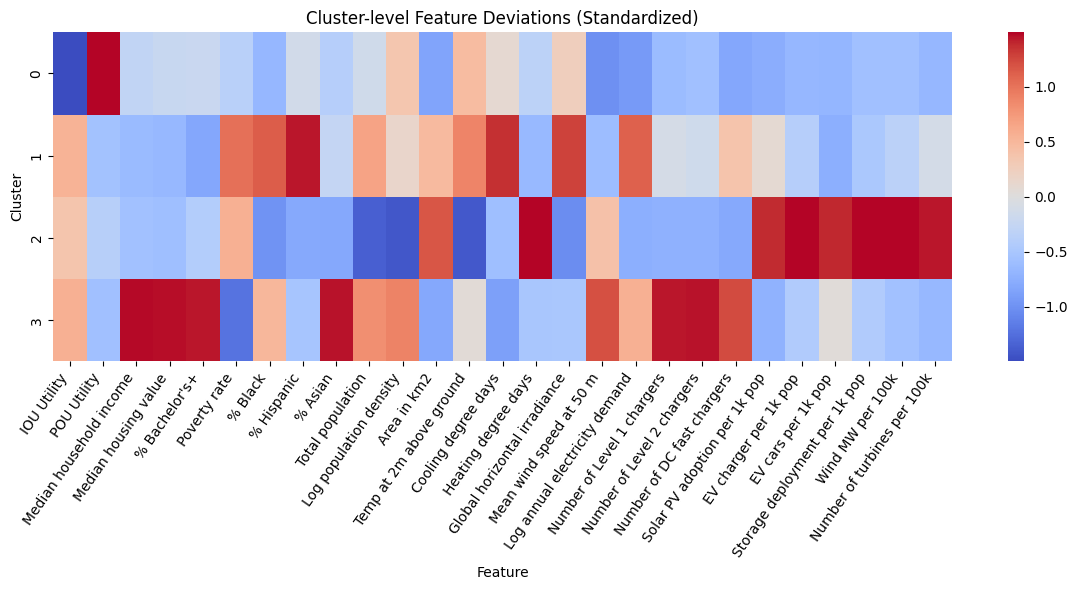

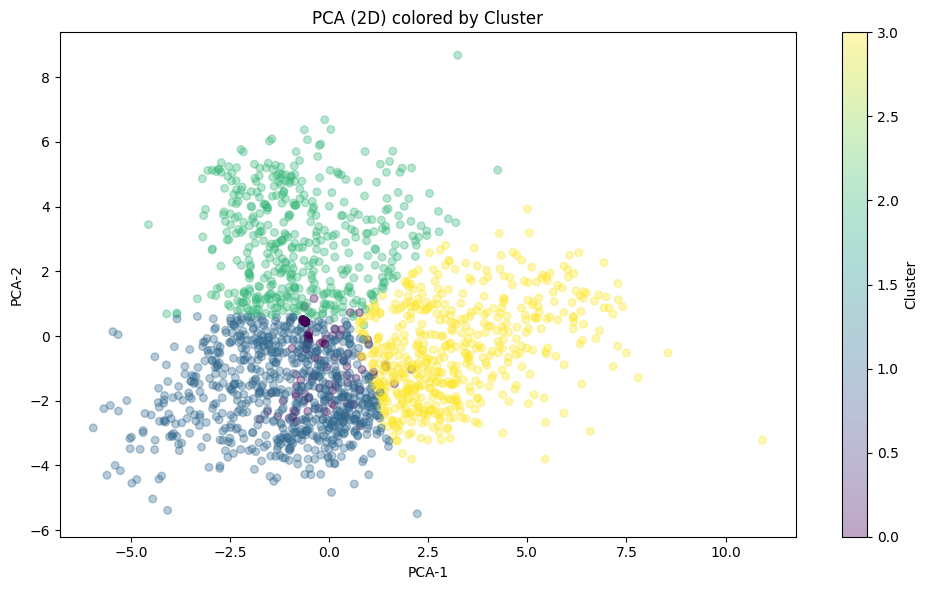

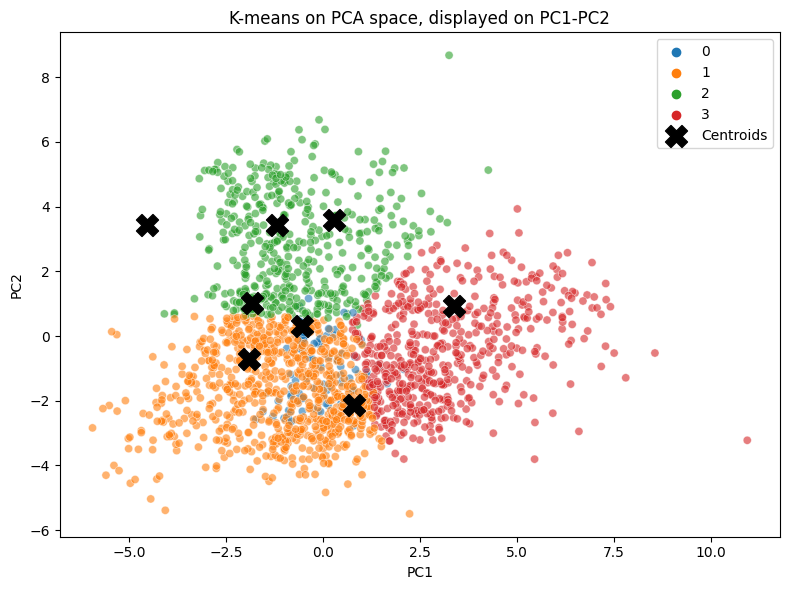

cluster_z_pca
0    856
1    578
2    413
3    324
4    401
Name: count, dtype: int64
Explained variance ratio:
PC1    0.150760
PC2    0.134922
PC3    0.091608
Name: explained_variance_ratio, dtype: float64

Top 10 loadings for PC1:
Median housing value            0.411015
% Bachelor's+                   0.392034
Median household income         0.389040
% Asian                         0.300481
Cooling degree days            -0.295259
Log population density          0.232808
% Hispanic                     -0.193130
Global horizontal irradiance   -0.192119
wind_ws10m_mean_2024            0.189677
Poverty rate                   -0.188826
Name: PC1, dtype: float64

Top 10 loadings for PC2:
Heating degree days              0.417450
Temp at 2m above ground         -0.417133
Total population                -0.324497
Log population density          -0.314454
% Hispanic                      -0.296474
Log annual electricity demand   -0.294748
Global horizontal irradiance    -0.278026
Cooling degr

,PC1,PC2,PC3,top_pc
Median housing value,0.411015,0.016458,0.054645,PC1
% Bachelor's+,0.392034,0.035064,0.064047,PC1
Median household income,0.389040,0.009545,0.020952,PC1
% Asian,0.300481,0.142164,0.026299,PC1
Cooling degree days,0.295259,0.257854,0.040141,PC1
Log population density,0.232808,0.314454,0.236575,PC2
% Hispanic,0.193130,0.296474,0.097200,PC2
Global horizontal irradiance,0.192119,0.278026,0.004702,PC2
wind_ws10m_mean_2024,0.189677,0.009155,0.103264,PC1
Poverty rate,0.188826,0.040387,0.143627,PC1



Cluster mean feature profiles (standardized):


,IOU Utility,POU Utility,Number of Level 1 chargers,Number of Level 2 chargers,Number of DC fast chargers,Median household income,Poverty rate,% Bachelor's+,% Black,% Hispanic,...,Mean wind speed at 50 m,Log annual electricity demand,Area in km2,Log population density,Solar PV adoption per 1k pop,EV charger per 1k pop,EV cars per 1k pop,Storage deployment per 1k pop,Wind MW per 100k,Number of turbines per 100k
cluster,,,,,,,,,,,,,,,,,,,,,
0,-1.78,1.78,-0.79,-0.60,-1.02,-0.28,-0.35,-0.20,-0.66,-0.23,...,-0.76,-0.97,-0.79,0.35,-0.76,-0.72,-0.68,-0.73,-0.71,-0.76
1,0.54,-0.54,0.98,0.26,1.03,-0.00,-0.34,0.00,1.59,0.59,...,-0.93,1.48,-0.63,0.90,-0.67,-0.71,-0.70,-0.71,-0.70,-0.69
2,0.28,-0.28,-0.92,-0.74,-0.94,-0.50,0.31,-0.34,-1.02,-0.93,...,0.08,-0.83,0.92,-1.40,0.56,1.69,1.55,0.15,1.44,1.17
3,0.52,-0.52,1.17,1.64,1.01,1.69,-1.15,1.63,0.05,-0.85,...,1.60,-0.10,-0.75,0.81,-0.64,-0.32,0.48,-0.39,-0.70,-0.74
4,0.45,-0.45,-0.44,-0.57,-0.09,-0.91,1.53,-1.09,0.04,1.42,...,0.00,0.42,1.25,-0.67,1.50,0.06,-0.64,1.67,0.66,1.02


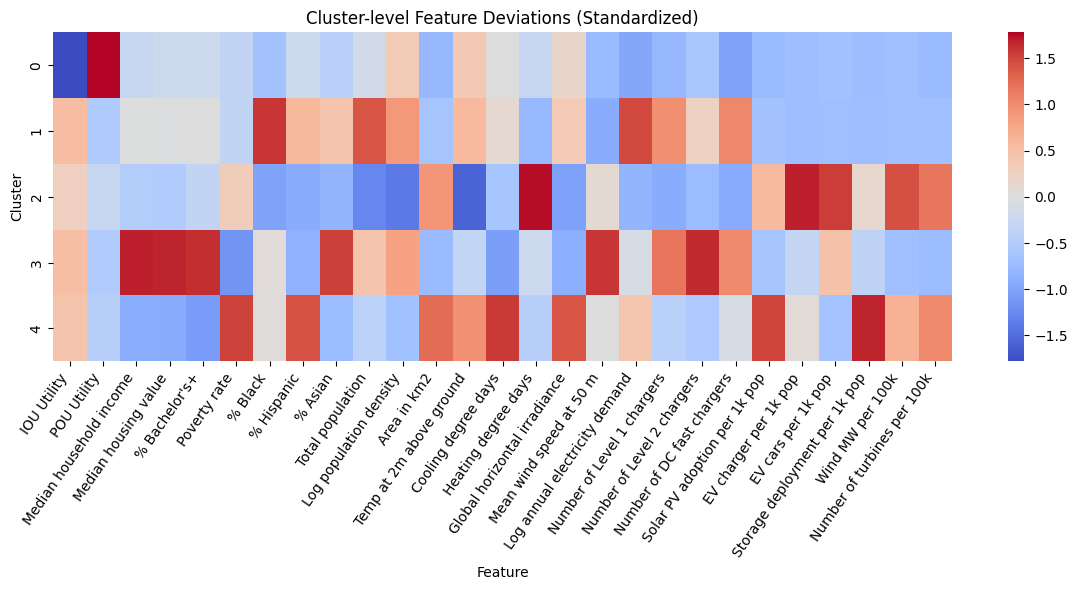

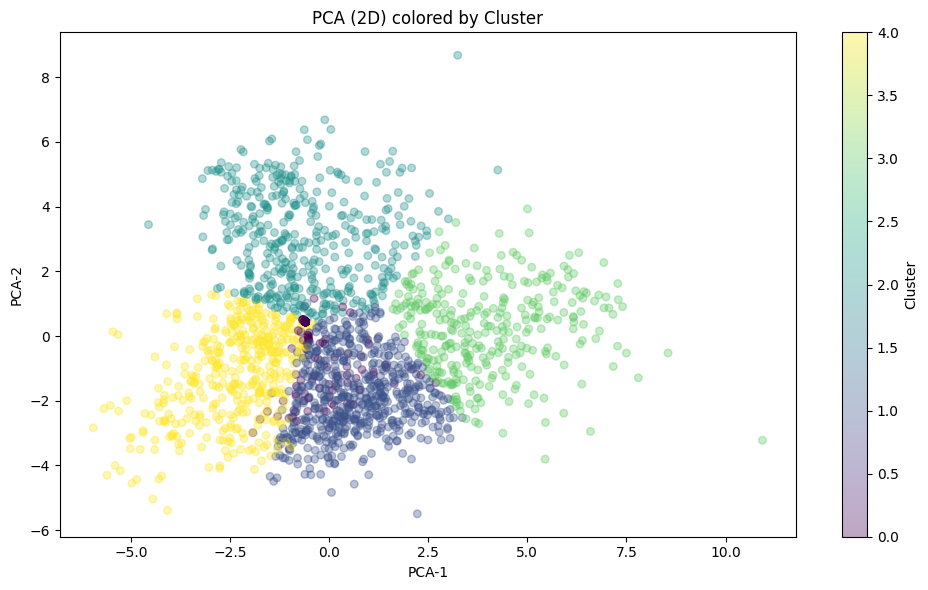

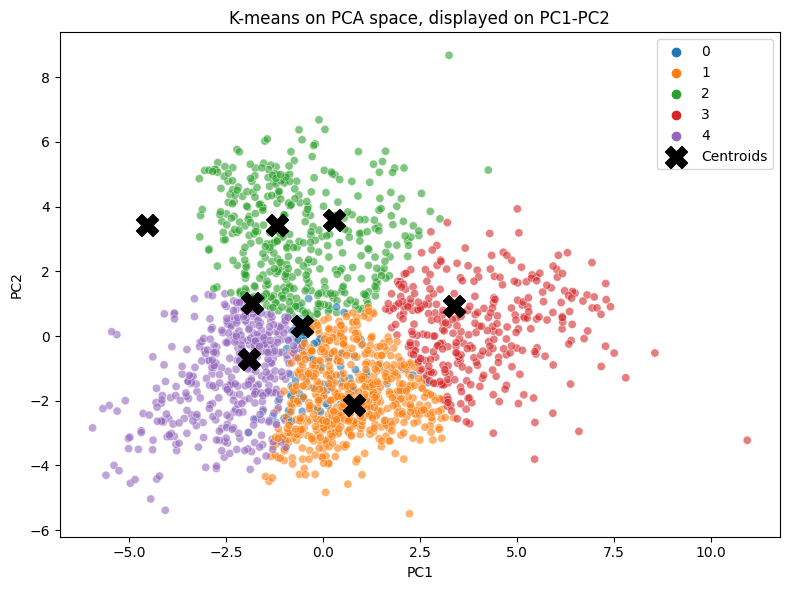

cluster_z_pca
0    874
1    391
2    561
3    475
4    271
Name: count, dtype: int64
Explained variance ratio:
PC1    0.150760
PC2    0.134922
PC3    0.091608
PC4    0.073930
PC5    0.066488
Name: explained_variance_ratio, dtype: float64

Top 10 loadings for PC1:
Median housing value            0.411015
% Bachelor's+                   0.392034
Median household income         0.389040
% Asian                         0.300481
Cooling degree days            -0.295259
Log population density          0.232808
% Hispanic                     -0.193130
Global horizontal irradiance   -0.192119
wind_ws10m_mean_2024            0.189677
Poverty rate                   -0.188826
Name: PC1, dtype: float64

Top 10 loadings for PC2:
Heating degree days              0.417450
Temp at 2m above ground         -0.417133
Total population                -0.324497
Log population density          -0.314454
% Hispanic                      -0.296474
Log annual electricity demand   -0.294748
Global horizontal irra

,PC1,PC2,PC3,PC4,PC5,top_pc
Median housing value,0.411015,0.016458,0.054645,0.029714,0.027728,PC1
% Bachelor's+,0.392034,0.035064,0.064047,0.002510,0.035895,PC1
Median household income,0.389040,0.009545,0.020952,0.021440,0.054961,PC1
% Asian,0.300481,0.142164,0.026299,0.029703,0.100644,PC1
Cooling degree days,0.295259,0.257854,0.040141,0.046227,0.174204,PC1
Log population density,0.232808,0.314454,0.236575,0.017919,0.100551,PC2
% Hispanic,0.193130,0.296474,0.097200,0.020527,0.001088,PC2
Global horizontal irradiance,0.192119,0.278026,0.004702,0.047443,0.103881,PC2
wind_ws10m_mean_2024,0.189677,0.009155,0.103264,0.355681,0.357171,PC5
Poverty rate,0.188826,0.040387,0.143627,0.108609,0.093172,PC1



Cluster mean feature profiles (standardized):


,IOU Utility,POU Utility,Number of Level 1 chargers,Number of Level 2 chargers,Number of DC fast chargers,Median household income,Poverty rate,% Bachelor's+,% Black,% Hispanic,...,Mean wind speed at 50 m,Log annual electricity demand,Area in km2,Log population density,Solar PV adoption per 1k pop,EV charger per 1k pop,EV cars per 1k pop,Storage deployment per 1k pop,Wind MW per 100k,Number of turbines per 100k
cluster,,,,,,,,,,,,,,,,,,,,,
0,-1.77,1.77,-0.73,-0.66,-0.98,-0.24,-0.45,-0.17,-0.60,-0.18,...,-0.34,-0.79,-0.81,0.44,-0.60,-0.96,-0.66,-0.73,-0.46,-0.46
1,0.54,-0.54,1.18,1.37,0.49,1.66,-1.12,1.61,0.06,-0.79,...,1.53,-0.40,-0.63,0.50,-0.29,0.91,1.71,0.12,-0.46,-0.45
2,0.56,-0.56,0.99,0.77,1.49,0.12,-0.41,0.13,1.58,0.81,...,-0.76,1.68,-0.73,1.09,-0.59,-0.97,-0.73,-0.76,-0.46,-0.46
3,0.49,-0.49,-0.59,-0.63,-0.28,-0.82,1.45,-1.04,0.03,1.24,...,0.44,0.12,0.94,-0.62,1.77,-0.11,-0.33,1.67,1.79,1.79
4,0.17,-0.17,-0.86,-0.85,-0.72,-0.71,0.52,-0.53,-1.07,-1.08,...,-0.87,-0.60,1.23,-1.41,-0.29,1.14,-0.00,-0.30,-0.40,-0.42


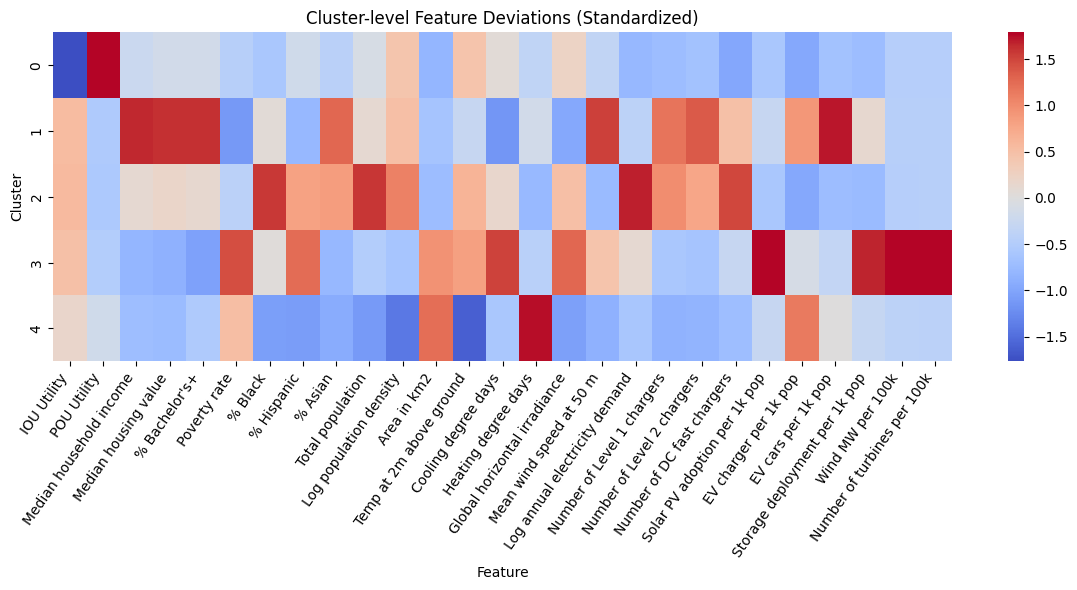

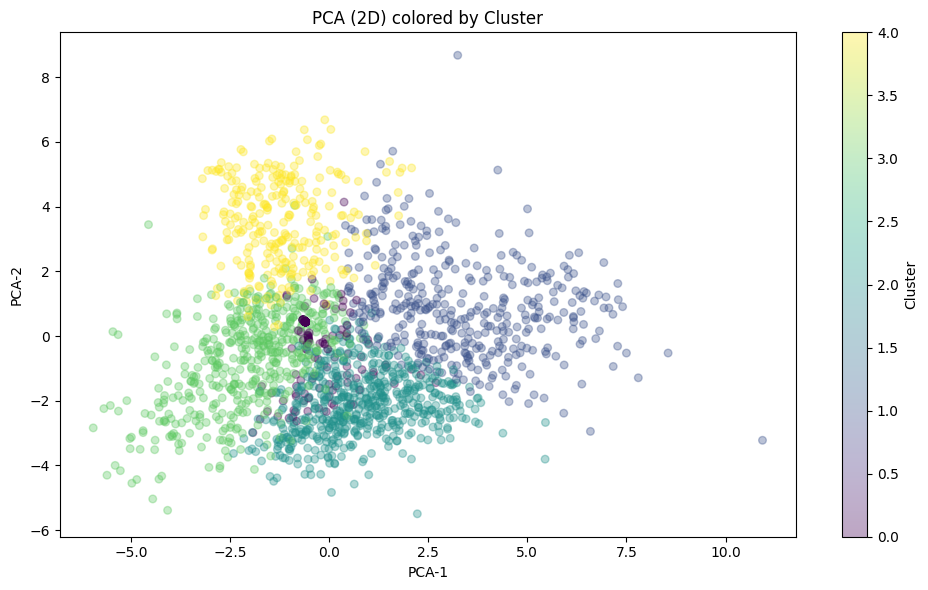

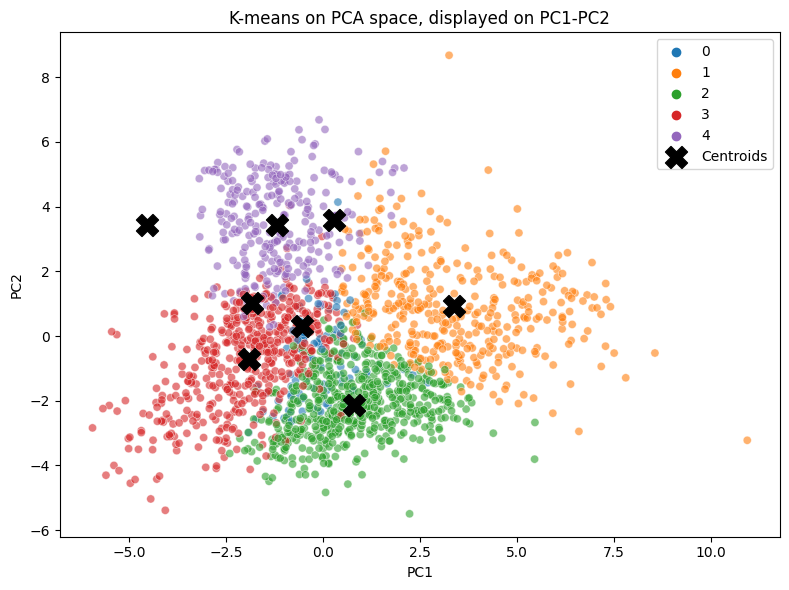

In [11]:
def pca_cluster_vis(n_components, n_clusters):
    pca, df_viz_pca, Z = set_up_pca_kmeans(n_components = n_components,
                                        n_clusters = n_clusters)
    # =========================
    # 1) PCA loadings
    # =========================
    loadings = pd.DataFrame(
        pca.components_.T,                      # rows = features
        index=X.columns,                        # feature names used in PCA
        columns=[f"PC{i+1}" for i in range(pca.n_components_)]
    )

    # Optional: variance explained
    explained = pd.Series(
        pca.explained_variance_ratio_,
        index=loadings.columns,
        name="explained_variance_ratio"
    )
    print("Explained variance ratio:")
    print(explained)

    # Top features by absolute loading for each PC
    top_n = 10
    for pc in loadings.columns:
        s = loadings[pc]
        top = s.abs().sort_values(ascending=False).head(top_n).index
        print(f"\nTop {top_n} loadings for {pc}:")
        print(loadings.loc[top, pc].sort_values(key=np.abs, ascending=False))

    # =========================
    # 2) Dominant PC per feature
    # =========================
    top_features = (
        loadings.abs()
        .assign(top_pc=loadings.abs().idxmax(axis=1))
    )

    print("\nTop contributing features to PCA components:")
    display(top_features.sort_values(by=loadings.columns.tolist(), ascending=False).head(10))

    # =========================
    # 3) Cluster-level means
    # =========================
    # It must line up row-for-row with X.
    cluster_labels = df_viz_pca["cluster_z_pca"]   # <-- change this only if needed

    # Align cluster labels to X rows
    cluster_labels = pd.Series(cluster_labels.values, index=X.index, name="cluster")

    cluster_means = (
        X.assign(cluster=cluster_labels)
        .groupby("cluster")
        .mean()
    )
    ordered_cols = [
        # Utility / institutional
        "IOU Utility",
        "POU Utility",

        # Socioeconomic / demographic
        "Median household income",
        "Median housing value",
        "% Bachelor's+",
        "Poverty rate",
        "% Black",
        "% Hispanic",
        "% Asian",
        "Total population",
        "Log population density",
        "Area in km2",

        # Climate / resource
        "Temp at 2m above ground",
        "Cooling degree days",
        "Heating degree days",
        "Global horizontal irradiance",
        "Mean wind speed at 50 m",
        "Log annual electricity demand",

        # DER / infrastructure counts
        "Number of Level 1 chargers",
        "Number of Level 2 chargers",
        "Number of DC fast chargers",

        # DER adoption / deployment outcomes
        "Solar PV adoption per 1k pop",
        "EV charger per 1k pop",
        "EV cars per 1k pop",
        "Storage deployment per 1k pop",
        "Wind MW per 100k",
        "Number of turbines per 100k",
    ]


    # Standardize cluster means across clusters for comparability
    cluster_means_standard = (cluster_means - cluster_means.mean()) / cluster_means.std()

    print("\nCluster mean feature profiles (standardized):")
    display(cluster_means_standard.round(2))

    # =========================
    # 4) Heatmap
    # =========================
    plt.figure(figsize=(12, 6))
    sns.heatmap(cluster_means_standard[ordered_cols], cmap="coolwarm", center=0, annot=False)
    plt.title("Cluster-level Feature Deviations (Standardized)")
    plt.xlabel("Feature")
    plt.xticks(rotation = 55, horizontalalignment="right")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

    plot_clusters(Z, df_viz_pca)
    return df_viz_pca

for n_comp, n_clust in ((3, 4), (3, 5), (5, 5)):
    df_viz_pca = pca_cluster_vis(n_comp, n_clust)

Put cloropleth plot of ca

In [13]:
# -----------------------------
# 1) Prepare cluster dataframe
# -----------------------------
# Example: cluster labels already aligned to your original dataframe
# Replace these names with your actual dataframe / column names

cluster_map = pd.DataFrame({
    "zip_code": analysis_df["zip_code"].astype(str).str.zfill(5),
    "cluster": cluster_z_pca.astype(int)
}).drop_duplicates(subset="zip_code")

# -----------------------------
# 2) Prepare California ZCTA shapefile
# -----------------------------
# Replace path with your actual shapefile path
zcta_gdf = gpd.read_file("tl_2023_us_zcta520.shp")

# Keep California ZIP/ZCTAs only if you already have a CA-only subset key.
# If not, easiest is to merge first and then drop nulls.
zcta_gdf["ZCTA5CE20"] = zcta_gdf["ZCTA5CE20"].astype(str).str.zfill(5)

# -----------------------------
# 3) Merge shapes with clusters
# -----------------------------
map_gdf = zcta_gdf.merge(
    cluster_map,
    left_on="ZCTA5CE20",
    right_on="zip_code",
    how="inner"
)

# -----------------------------
# 4) Plot choropleth
# -----------------------------
fig, ax = plt.subplots(1, 1, figsize=(10, 12))

map_gdf.plot(
    column="cluster",
    categorical=True,
    legend=True,
    linewidth=0.2,
    edgecolor="white",
    ax=ax
)

ax.set_title("California ZIP Code Clusters", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

NameError: name 'analysis_df' is not defined